### lab 06 : SUPPORT VECTOR MACHINE (SVM) CLASSIFIER

- NAME : MUHAMMAD FASIH
- ROLL NO : 24F-AI-016

### LAB TASK : 01

- Load a dataset for classification (e.g., Parkinson disease)

In [8]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

cancer= load_breast_cancer()

# Create DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Add target
df["target"] = cancer.target 

X = cancer.data
y = cancer.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", cancer.target_names)

Feature shape: (569, 30)
Target shape: (569,)
Classes: ['malignant' 'benign']


### Task 02 : Data preprocessing.

- Apply data preprocessing (handle missing values, encode categorical data).



In [9]:

from sklearn.impute import SimpleImputer

# Separate features and target
X = df.drop(columns="target")
y = df["target"]

# Handle missing values
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Combine X and y
df_preprocessed = X.copy()
df_preprocessed["target"] = y

# Check missing values
print("Missing values:", df_preprocessed.isnull().sum().sum())

print(df_preprocessed.head())

Missing values: 0
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area

## tak 03 : Training and Testing Dataset
- Split the dataset into training and testing sets.

In [10]:
from sklearn.model_selection import train_test_split

# Split features and target into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


### task 04 : Applying Grid Search

-  Apply Grid search to find the optimal parameters 

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Create model
model = DecisionTreeClassifier(random_state=42)

# Parameters we want to try
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

# Apply Grid Search
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="accuracy"
)

# Train Grid Search
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best accuracy
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 5}
Best Accuracy: 0.9384615384615385


### task 05 : predictions
- 5. Use those parameters to make predictions on the test set.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Use the best model found by grid search
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("Predicted labels:", y_pred[:10].tolist())
print("Actual labels:", y_test[:10].tolist())



Best Parameters: {'max_depth': 5, 'min_samples_split': 5}
Predicted labels: [0, 1, 0, 1, 0, 1, 1, 0, 0, 0]
Actual labels: [0, 1, 0, 1, 0, 1, 1, 0, 0, 0]
Accuracy: 0.9210526315789473
Confusion Matrix:
 [[39  3]
 [ 6 66]]
              precision    recall  f1-score   support

   malignant       0.87      0.93      0.90        42
      benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



In [14]:
## accuracy score
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)
print(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))

Accuracy: 0.9210526315789473
Confusion Matrix:
 [[39  3]
 [ 6 66]]
              precision    recall  f1-score   support

   malignant       0.87      0.93      0.90        42
      benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



### task 06 : performance
- Evaluate performance using accuracy, precision, recall, and F1-score.



In [15]:
from sklearn.metrics import accuracy_score
# accuracy score

accuracy = accuracy_score(y_test,y_pred)
print("Accuracy of the model on test data:", accuracy)  

Accuracy of the model on test data: 0.9210526315789473


In [17]:
# precision score

from sklearn.metrics import precision_score

precision = precision_score(y_test,y_pred)
print("Precision of the model on test data:", precision)

Precision of the model on test data: 0.9565217391304348


In [18]:
from sklearn.metrics import recall_score

# recall score

recall = recall_score(y_test,y_pred)
print("Recall of the model on test data:",recall_score)

Recall of the model on test data: <function recall_score at 0x000002818B8423E0>


In [20]:
from sklearn.metrics import f1_score

# f1 score

score = f1_score(y_test,y_pred)
print("f1 score of the model on test dara:",score)

f1 score of the model on test dara: 0.9361702127659575


### task 07 Visualize the Confusion Matrix.


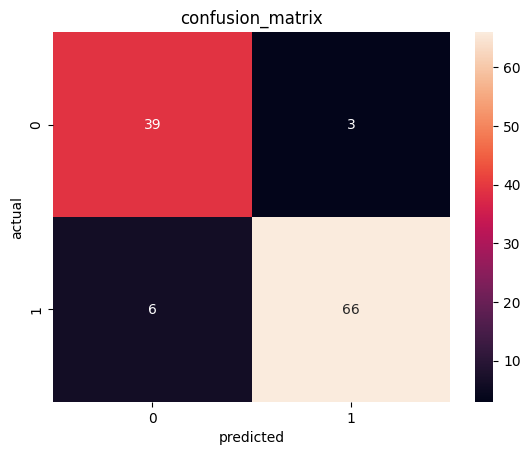

In [21]:
from sklearn.metrics import confusion_matrix

import seaborn as sns
from matplotlib import pyplot as plt

cm = confusion_matrix(y_test,y_pred)

heatmap = sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion_matrix")

plt.show()